# Early-Detection Optuna Study Report

## Executive Summary

This report reviews the completed early-detection optimization study built
from `reports/early_detection_trials.csv` and
`models/early_detection_best.json`. The study objective maximizes the
recorded detection metric while applying an earliness penalty, so the
selected configuration is the best operational tradeoff found by the
search rather than the highest raw detection metric alone.

Key findings from this run:

- The study completed all 100 configured trials; 99 trials were feasible.
- The selected configuration is trial 85: a random forest using prefix
  access through sensor index 155, or 26.3% of the sensor sequence.
- Trial 85 recorded PR-AUC 0.224 and penalized score 0.198.
- Random forest produced the strongest family-level result; XGBoost was
  the closest challenger and reached a near-best objective at earlier
  observation.
- Prefix access and no feature selection were the strongest categorical
  choices by median objective in this sampled study.

The trial artifact does not record ROC-AUC or held-out test metrics. Those
measures require a separate evaluation artifact and should be treated as
out of scope for this report.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.rcParams.update(
    {
        "figure.figsize": (11, 5),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)


In [2]:
def find_repo_root() -> Path:
    # Return the repository root from the current notebook working directory.
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / "reports/early_detection_trials.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find reports/early_detection_trials.csv")


REPO_ROOT = find_repo_root()
TRIALS_CSV = REPO_ROOT / "reports/early_detection_trials.csv"
BEST_JSON = REPO_ROOT / "models/early_detection_best.json"

trials_raw = pd.read_csv(TRIALS_CSV)
best_record = json.loads(BEST_JSON.read_text(encoding="utf-8"))

print(f"Repo root: {REPO_ROOT}")
print(f"Trials CSV: {TRIALS_CSV}")
print(f"Best-trial JSON: {BEST_JSON}")


Repo root: C:\Users\Virgil\Code\semiconductor-yield-root-cause
Trials CSV: C:\Users\Virgil\Code\semiconductor-yield-root-cause\reports\early_detection_trials.csv
Best-trial JSON: C:\Users\Virgil\Code\semiconductor-yield-root-cause\models\early_detection_best.json


In [3]:
trials = trials_raw.rename(
    columns={
        "number": "trial",
        "value": "penalized_score",
        "user_attrs_detection_metric": "detection_metric",
        "user_attrs_observation_fraction": "observation_fraction",
        "user_attrs_latest_index": "latest_index",
        "user_attrs_n_features_selected": "n_features_selected",
        "user_attrs_feasible": "feasible",
        "params_access_type": "access_type",
        "params_model_family": "model_family",
        "params_selection_method": "selection_method",
        "params_cv_threshold": "cv_threshold",
        "params_missing_threshold": "missing_threshold",
        "params_correlation_threshold": "correlation_threshold",
    }
).copy()

numeric_columns = [
    "trial",
    "penalized_score",
    "detection_metric",
    "observation_fraction",
    "latest_index",
    "n_features_selected",
    "cv_threshold",
    "missing_threshold",
    "correlation_threshold",
    "params_threshold",
    "params_prefix_end",
    "params_window_start",
    "params_window_size",
]
for column in numeric_columns:
    if column in trials.columns:
        trials[column] = pd.to_numeric(trials[column], errors="coerce")

trials["duration_seconds"] = pd.to_timedelta(
    trials["duration"], errors="coerce"
).dt.total_seconds()
trials["feasible"] = trials["feasible"].astype(str).str.lower().eq("true")
trials["best_so_far_score"] = trials["penalized_score"].cummax()
trials["best_so_far_metric"] = trials["detection_metric"].cummax()
trials["log10_cv_threshold"] = np.log10(trials["cv_threshold"])

provenance = best_record.get("provenance", {})
metric_key = str(provenance.get("detection_metric", "detection_metric"))
metric_label = {
    "pr_auc": "PR-AUC",
    "roc_auc": "ROC-AUC",
    "recall_at_far": "Recall at FAR",
    "neg_balanced_error": "Negative balanced error",
    "neg_expected_cost": "Negative expected cost",
}.get(metric_key, metric_key)

trials.head()


,trial,penalized_score,datetime_start,datetime_complete,duration,access_type,correlation_threshold,cv_threshold,params_lightgbm_learning_rate,params_lightgbm_max_depth,...,feasible,latest_index,user_attrs_model_family,n_features_selected,observation_fraction,state,duration_seconds,best_so_far_score,best_so_far_metric,log10_cv_threshold
0,0,0.066990,2026-06-16 20:00:31.462866,2026-06-16 20:00:32.464498,0 days 00:00:01.001632,window,0.858132,0.002938,NaN,NaN,...,True,588,logistic_regression,86.8,0.996610,COMPLETE,1.001632,0.066990,0.166651,-2.532016
1,1,0.086035,2026-06-16 20:00:32.464498,2026-06-16 20:00:36.617601,0 days 00:00:04.153103,window,0.921993,0.003972,NaN,NaN,...,True,337,random_forest,22.0,0.571186,COMPLETE,4.153103,0.086035,0.166651,-2.400979
2,2,0.090936,2026-06-16 20:00:36.618602,2026-06-16 20:00:42.620491,0 days 00:00:06.001889,window,0.981530,0.211543,NaN,NaN,...,True,376,xgboost,36.2,0.637288,COMPLETE,6.001889,0.090936,0.166651,-0.674602
3,3,0.054991,2026-06-16 20:00:42.637534,2026-06-16 20:00:50.002490,0 days 00:00:07.364956,prefix,0.850773,0.003946,0.034993,2.0,...,True,583,lightgbm,228.6,0.988136,COMPLETE,7.364956,0.090936,0.166651,-2.403853
4,4,0.084230,2026-06-16 20:00:50.002490,2026-06-16 20:00:57.468150,0 days 00:00:07.465660,prefix,0.949854,0.002284,NaN,NaN,...,True,524,logistic_regression,109.0,0.888136,COMPLETE,7.465660,0.090936,0.173043,-2.641217


## Study Inputs And Metric Definitions

The trials CSV is an Optuna trials dataframe with one row per sampled
configuration. The `value` column is renamed to `penalized_score` and is
the objective Optuna optimized. Sampled search choices live in `params_*`
columns, while trial diagnostics and recorded outcomes live in
`user_attrs_*` columns.

The study provenance identifies `user_attrs_detection_metric` as PR-AUC.
Throughout this report, PR-AUC is therefore the raw detection metric and
`penalized_score` is PR-AUC adjusted by the configured earliness penalty.

ROC-AUC is not present in this CSV. To report ROC-AUC by trial, the
objective would need to persist it as another trial user attribute or a
downstream evaluation step would need to compute it from saved predictions.

In [4]:
column_inventory = []
for column in trials_raw.columns:
    if column in {"number", "value", "state", "duration"}:
        group = "Optuna core"
    elif column.startswith("params_"):
        group = "Sampled parameter"
    elif column.startswith("user_attrs_"):
        group = "Recorded metric / attribute"
    elif column.startswith("datetime_"):
        group = "Timing"
    else:
        group = "Other"
    column_inventory.append({"group": group, "column": column})

display(pd.DataFrame(column_inventory).sort_values(["group", "column"]))

recorded_metrics = pd.DataFrame(
    [
        {
            "csv column": "value",
            "notebook name": "penalized_score",
            "meaning": "Optuna objective: detection metric minus earliness penalty",
        },
        {
            "csv column": "user_attrs_detection_metric",
            "notebook name": "detection_metric",
            "meaning": f"Raw inner-CV {metric_label} for this run",
        },
        {
            "csv column": "user_attrs_observation_fraction",
            "notebook name": "observation_fraction",
            "meaning": "Latest observed sensor index divided by total sensor count",
        },
        {
            "csv column": "user_attrs_latest_index",
            "notebook name": "latest_index",
            "meaning": "Latest sensor index needed by the sampled access pattern",
        },
        {
            "csv column": "user_attrs_n_features_selected",
            "notebook name": "n_features_selected",
            "meaning": "Mean retained/selected feature count across inner folds",
        },
        {
            "csv column": "duration",
            "notebook name": "duration_seconds",
            "meaning": "Wall-clock duration of the Optuna trial",
        },
    ]
)
display(recorded_metrics)


,group,column
4,Optuna core,duration
0,Optuna core,number
39,Optuna core,state
1,Optuna core,value
32,Recorded metric / attribute,user_attrs_access_type
33,Recorded metric / attribute,user_attrs_detection_metric
34,Recorded metric / attribute,user_attrs_feasible
35,Recorded metric / attribute,user_attrs_latest_index
36,Recorded metric / attribute,user_attrs_model_family
37,Recorded metric / attribute,user_attrs_n_features_selected


,csv column,notebook name,meaning
0,value,penalized_score,Optuna objective: detection metric minus earli...
1,user_attrs_detection_metric,detection_metric,Raw inner-CV PR-AUC for this run
2,user_attrs_observation_fraction,observation_fraction,Latest observed sensor index divided by total ...
3,user_attrs_latest_index,latest_index,Latest sensor index needed by the sampled acce...
4,user_attrs_n_features_selected,n_features_selected,Mean retained/selected feature count across in...
5,duration,duration_seconds,Wall-clock duration of the Optuna trial


## Study Completion And Artifact Integrity

The first check confirms that the persisted trials table matches the study
configuration and that Optuna completed the planned search. This matters
because incomplete or failed trials can bias the summary plots that follow.

In [5]:
expected_trials = provenance.get("n_trials")
status_summary = pd.DataFrame(
    [
        {"check": "Configured trials", "value": expected_trials},
        {"check": "Rows in trials CSV", "value": len(trials)},
        {
            "check": "Complete rows",
            "value": int((trials["state"] == "COMPLETE").sum()),
        },
        {"check": "Feasible rows", "value": int(trials["feasible"].sum())},
        {
            "check": "Best trial",
            "value": int(best_record["best_trial_number"]),
        },
    ]
)
display(status_summary)

if expected_trials == len(trials) and (trials["state"] == "COMPLETE").all():
    display(Markdown("**Status:** study finished all configured trials."))
else:
    display(Markdown("**Status:** study is incomplete or has non-complete trials."))


,check,value
0,Configured trials,100
1,Rows in trials CSV,100
2,Complete rows,100
3,Feasible rows,99
4,Best trial,85


**Status:** study finished all configured trials.

## Selected Trial Configuration

The selected trial is the configuration with the highest penalized
objective. The summary below separates operational choices, preprocessing
thresholds, feature-selection policy, and model-specific hyperparameters so
the handoff configuration is explicit.

In [6]:
best_config = best_record["config"]
best_snapshot = pd.DataFrame(
    [
        ("best trial", best_record["best_trial_number"]),
        ("penalized score", best_record["penalized_score"]),
        (metric_label, best_record["detection_metric"]),
        ("observation fraction", best_record["observation_fraction"]),
        ("latest sensor index", best_record["latest_index"]),
        ("mean selected features", best_record["n_features_selected"]),
        ("access", best_config["access"]["access_type"]),
        ("model family", best_config["model_family"]),
        ("selection method", best_config["selection_method"]),
    ],
    columns=["field", "value"],
)
display(best_snapshot)

model_params = pd.DataFrame(
    best_config["model_params"].items(), columns=["model parameter", "value"]
)
display(model_params)


,field,value
0,best trial,85
1,penalized score,0.197619
2,PR-AUC,0.22389
3,observation fraction,0.262712
4,latest sensor index,155
5,mean selected features,72.6
6,access,prefix
7,model family,random_forest
8,selection method,none


,model parameter,value
0,n_estimators,613
1,max_depth,15
2,min_samples_leaf,13
3,max_features,sqrt
4,class_weight,balanced_subsample


## Trial-Level Outcome History

The following panels trace every recorded numeric outcome over the original
Optuna trial order. The objective panel includes the running best score,
which shows when the search discovered material improvements. Infeasible
trials are marked separately and should not be interpreted as valid model
candidates.

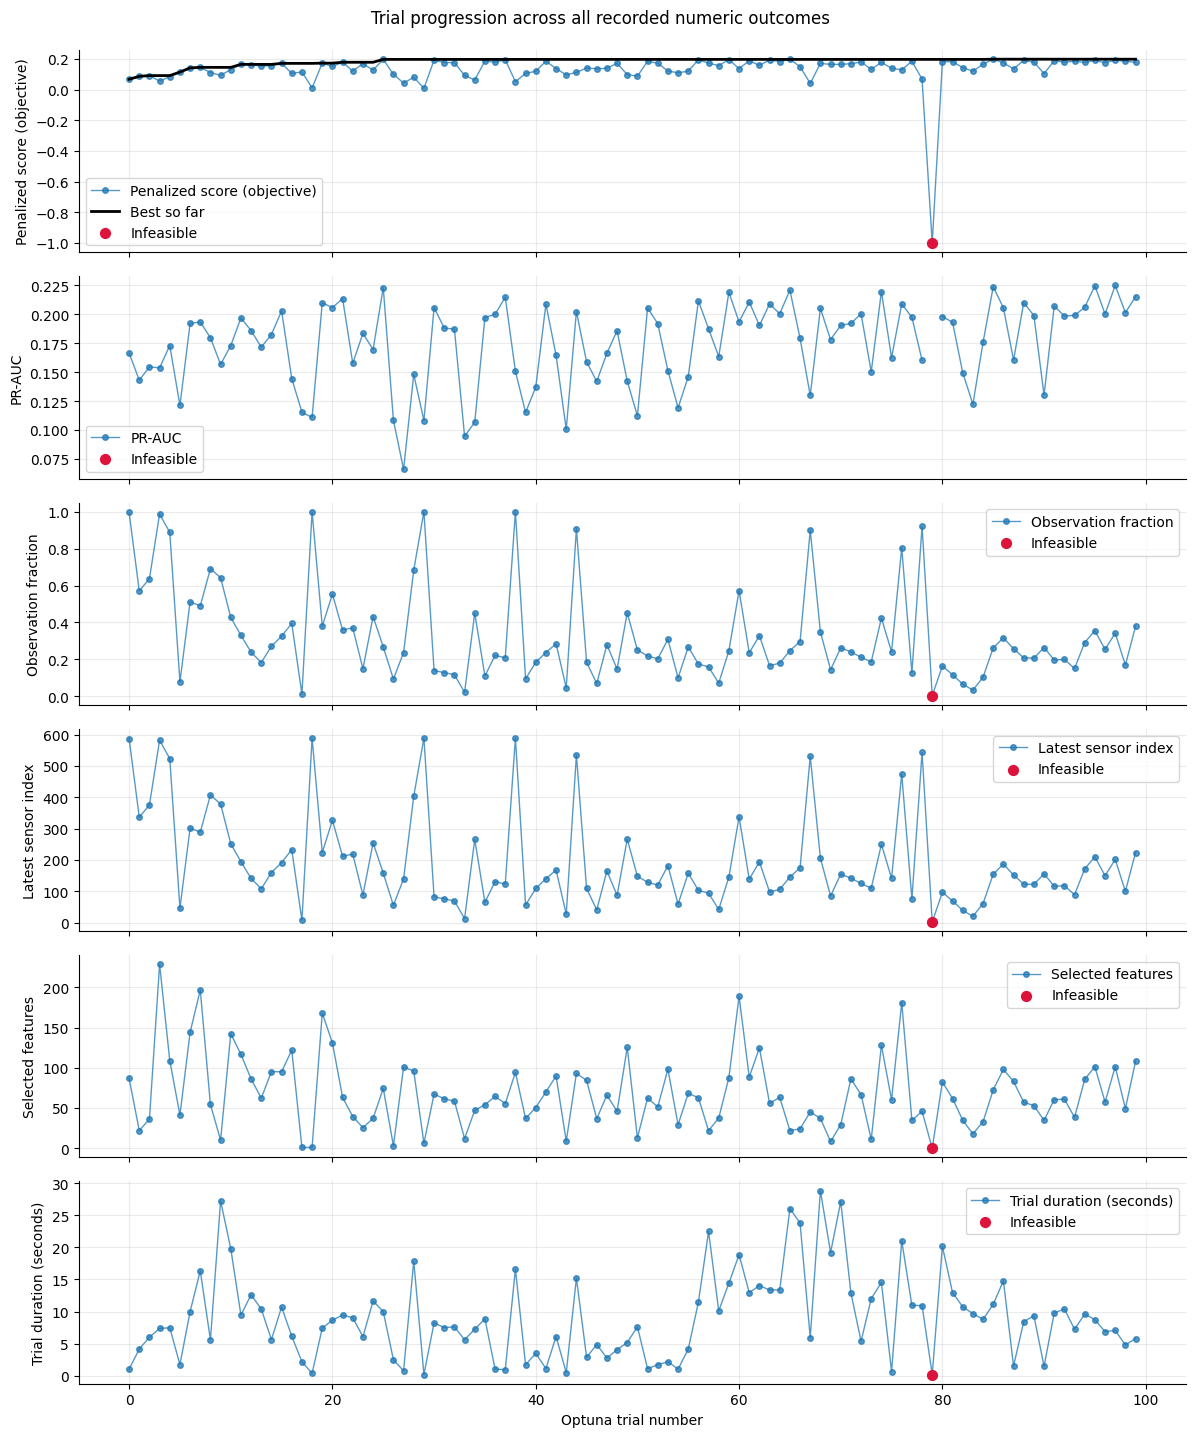

In [7]:
metric_specs = [
    ("penalized_score", "Penalized score (objective)"),
    ("detection_metric", metric_label),
    ("observation_fraction", "Observation fraction"),
    ("latest_index", "Latest sensor index"),
    ("n_features_selected", "Selected features"),
    ("duration_seconds", "Trial duration (seconds)"),
]
metric_specs = [
    (column, label)
    for column, label in metric_specs
    if column in trials.columns and trials[column].notna().any()
]

fig, axes = plt.subplots(
    len(metric_specs), 1, figsize=(12, 2.4 * len(metric_specs)), sharex=True
)
if len(metric_specs) == 1:
    axes = [axes]

infeasible = ~trials["feasible"]
for ax, (column, label) in zip(axes, metric_specs):
    ax.plot(
        trials["trial"],
        trials[column],
        marker="o",
        linewidth=1.0,
        markersize=4,
        alpha=0.75,
        label=label,
    )
    if column == "penalized_score":
        ax.plot(
            trials["trial"],
            trials["best_so_far_score"],
            color="black",
            linewidth=2,
            label="Best so far",
        )
    if infeasible.any():
        ax.scatter(
            trials.loc[infeasible, "trial"],
            trials.loc[infeasible, column],
            color="crimson",
            s=50,
            zorder=5,
            label="Infeasible",
        )
    ax.set_ylabel(label)
    ax.legend(loc="best")

axes[-1].set_xlabel("Optuna trial number")
fig.suptitle("Trial progression across all recorded numeric outcomes", y=0.995)
fig.tight_layout()
plt.show()


## Model-Family Performance

Optuna sampled model families unevenly, so this comparison is descriptive
rather than a controlled head-to-head benchmark. The table ranks families
by their best observed objective, and the panels below keep the original
trial numbers while filtering each metric history to one model family at a
time.

### Metrics By Model Family

,model_family,runs,feasible_runs,best_objective_trial,best_penalized_score,median_penalized_score,best_pr_auc,median_pr_auc,median_observation_fraction,median_duration_seconds
0,random_forest,64,63,85,0.197619,0.171061,0.224945,0.197246,0.247458,9.984578
1,xgboost,20,20,37,0.194023,0.119956,0.214870,0.155694,0.220339,2.329289
2,logistic_regression,8,8,75,0.138469,0.094635,0.173043,0.161559,0.337288,1.258115
3,lightgbm,8,8,40,0.118632,0.100452,0.160348,0.139709,0.358475,4.318135


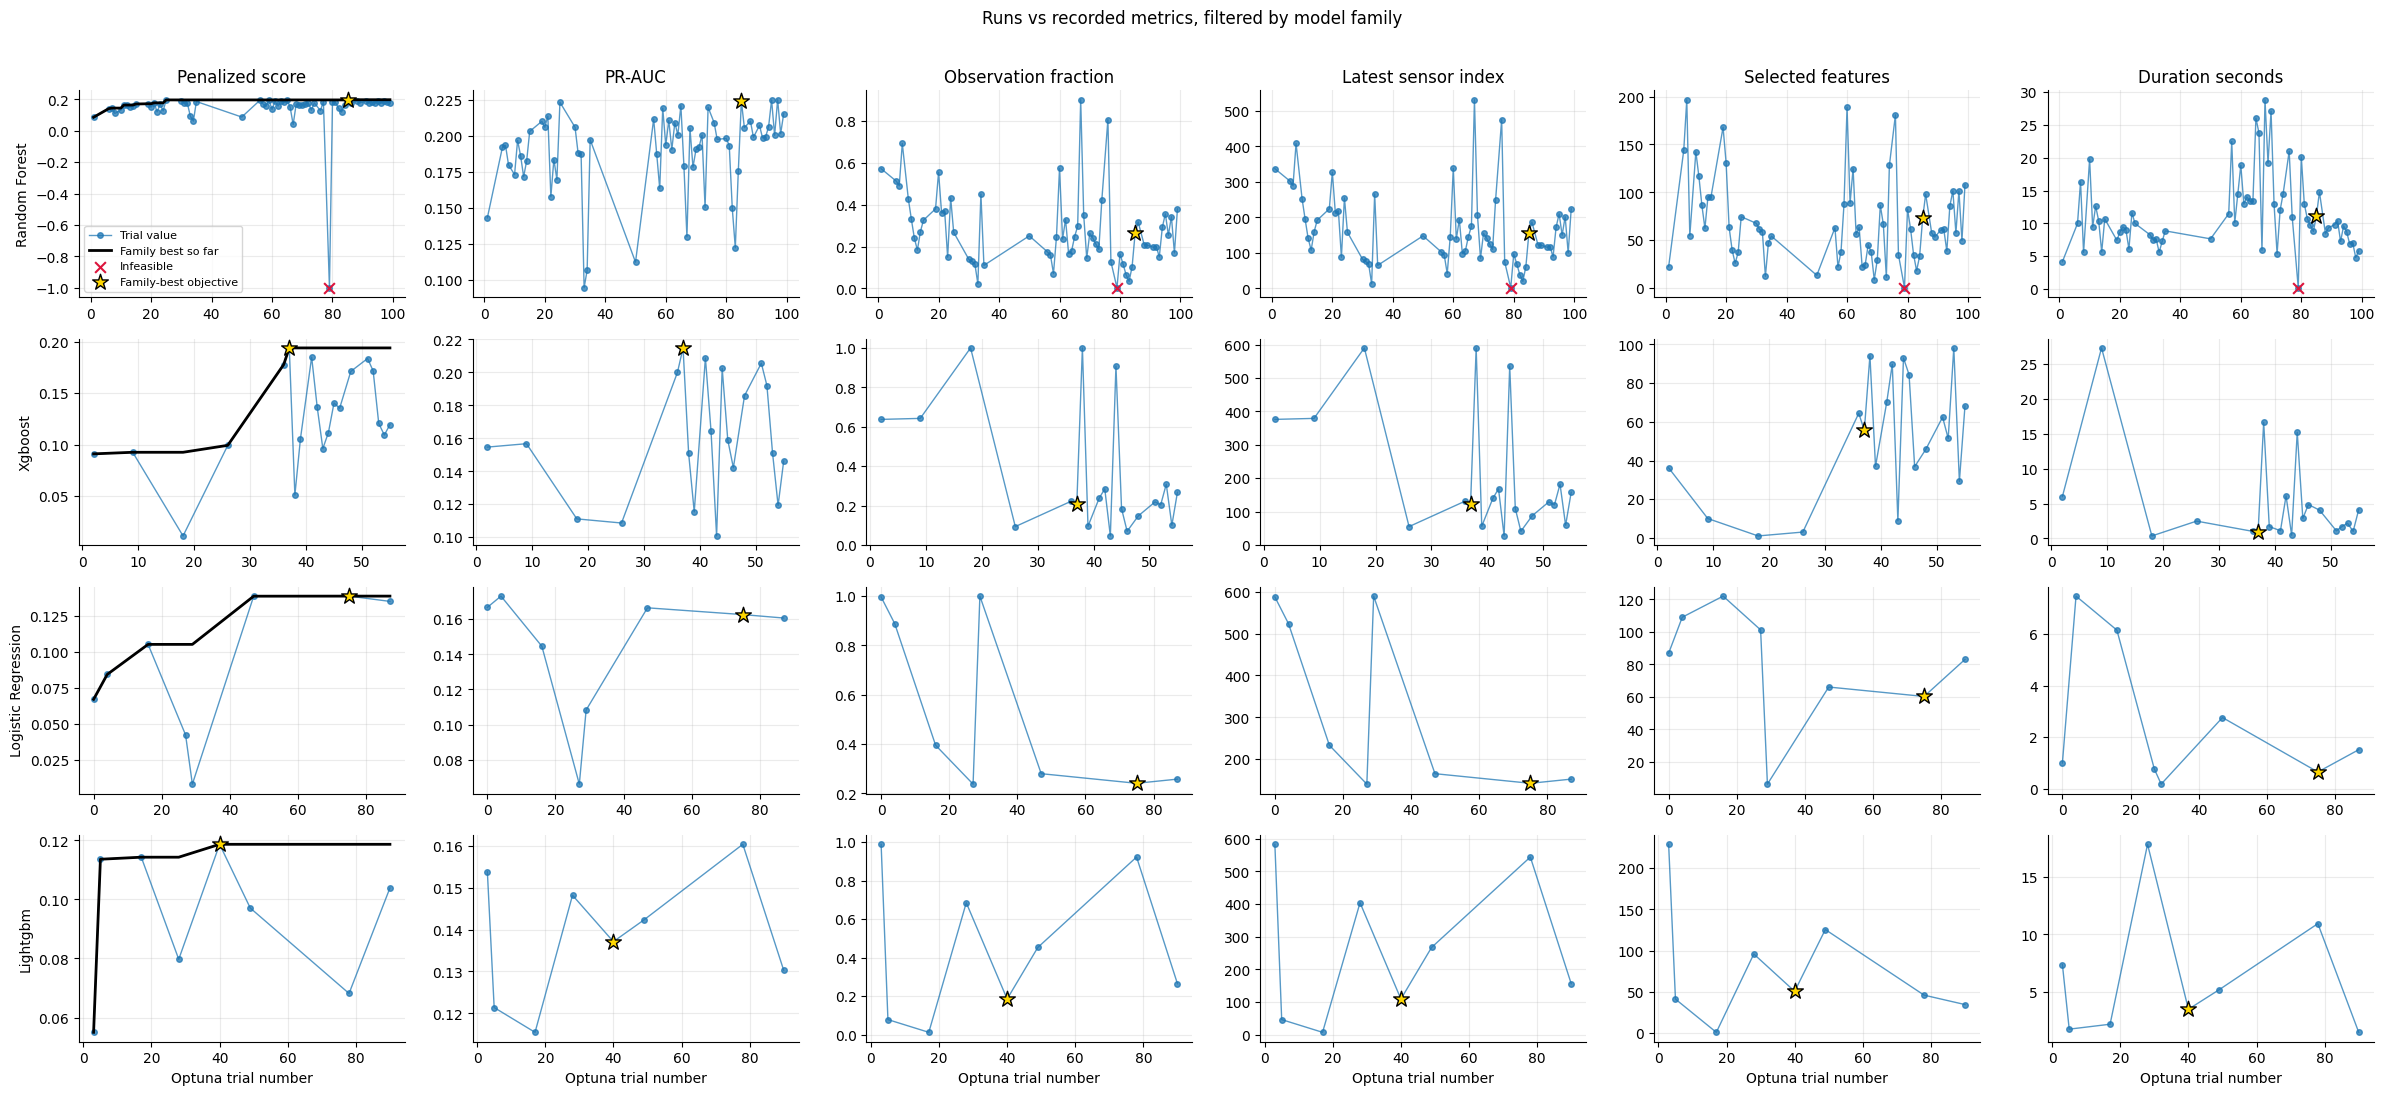

In [8]:
summary_rows: list[dict[str, object]] = []
for model_family, model_data in trials.groupby("model_family", sort=False):
    model_data = model_data.sort_values("trial")
    best_objective_idx = model_data["penalized_score"].idxmax()
    best_metric_idx = model_data["detection_metric"].idxmax()
    summary_rows.append(
        {
            "model_family": model_family,
            "runs": len(model_data),
            "feasible_runs": int(model_data["feasible"].sum()),
            "best_objective_trial": int(
                model_data.loc[best_objective_idx, "trial"]
            ),
            "best_penalized_score": model_data.loc[
                best_objective_idx, "penalized_score"
            ],
            "median_penalized_score": model_data["penalized_score"].median(),
            f"best_{metric_key}": model_data.loc[
                best_metric_idx, "detection_metric"
            ],
            f"median_{metric_key}": model_data["detection_metric"].median(),
            "median_observation_fraction": model_data[
                "observation_fraction"
            ].median(),
            "median_duration_seconds": model_data["duration_seconds"].median(),
        }
    )

model_metric_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("best_penalized_score", ascending=False)
    .reset_index(drop=True)
)
display(model_metric_summary)

model_families = model_metric_summary["model_family"].tolist()
per_model_metric_specs = [
    ("penalized_score", "Penalized score"),
    ("detection_metric", metric_label),
    ("observation_fraction", "Observation fraction"),
    ("latest_index", "Latest sensor index"),
    ("n_features_selected", "Selected features"),
    ("duration_seconds", "Duration seconds"),
]
per_model_metric_specs = [
    (column, label)
    for column, label in per_model_metric_specs
    if column in trials.columns and trials[column].notna().any()
]

fig, axes = plt.subplots(
    len(model_families),
    len(per_model_metric_specs),
    figsize=(4.0 * len(per_model_metric_specs), 2.7 * len(model_families)),
    squeeze=False,
)

for row_idx, model_family in enumerate(model_families):
    model_data = trials.loc[
        trials["model_family"] == model_family
    ].sort_values("trial")
    model_best_idx = model_data["penalized_score"].idxmax()
    family_label = model_family.replace("_", " ").title()

    for col_idx, (column, label) in enumerate(per_model_metric_specs):
        ax = axes[row_idx, col_idx]
        valid = model_data[column].notna()
        ax.plot(
            model_data.loc[valid, "trial"],
            model_data.loc[valid, column],
            marker="o",
            linewidth=1.0,
            markersize=4,
            alpha=0.75,
            label="Trial value",
        )
        if column == "penalized_score":
            ax.plot(
                model_data["trial"],
                model_data["penalized_score"].cummax(),
                color="black",
                linewidth=2,
                label="Family best so far",
            )
        infeasible = (~model_data["feasible"]) & valid
        if infeasible.any():
            ax.scatter(
                model_data.loc[infeasible, "trial"],
                model_data.loc[infeasible, column],
                color="crimson",
                marker="x",
                s=60,
                zorder=5,
                label="Infeasible",
            )
        if pd.notna(model_data.loc[model_best_idx, column]):
            ax.scatter(
                model_data.loc[model_best_idx, "trial"],
                model_data.loc[model_best_idx, column],
                color="gold",
                edgecolor="black",
                marker="*",
                s=140,
                zorder=6,
                label="Family-best objective",
            )
        if row_idx == 0:
            ax.set_title(label)
        if col_idx == 0:
            ax.set_ylabel(family_label)
        if row_idx == len(model_families) - 1:
            ax.set_xlabel("Optuna trial number")
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="best", fontsize=8)

fig.suptitle("Runs vs recorded metrics, filtered by model family", y=1.01)
fig.tight_layout()
plt.show()


### Model-Family Parameter History

These panels show how the conditional hyperparameters changed as Optuna
revisited each model family. Numeric parameters are plotted by original
trial number and colored by penalized score; categorical parameters use one
y-position per sampled option. The gold star marks the best objective trial
within that family.

Treat these plots as search diagnostics. They show what Optuna sampled and
where strong trials occurred, but they do not isolate causal sensitivity for
any single hyperparameter.

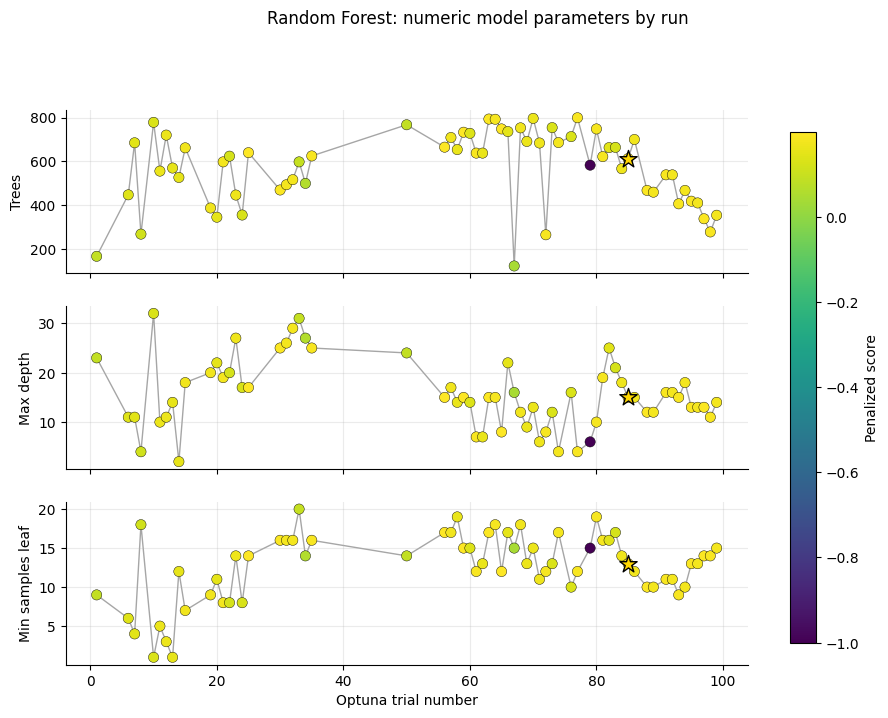

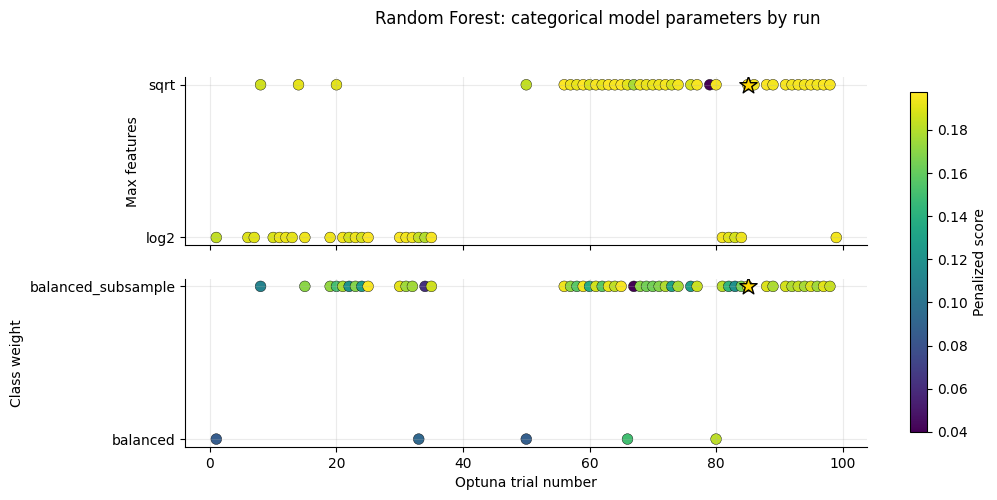

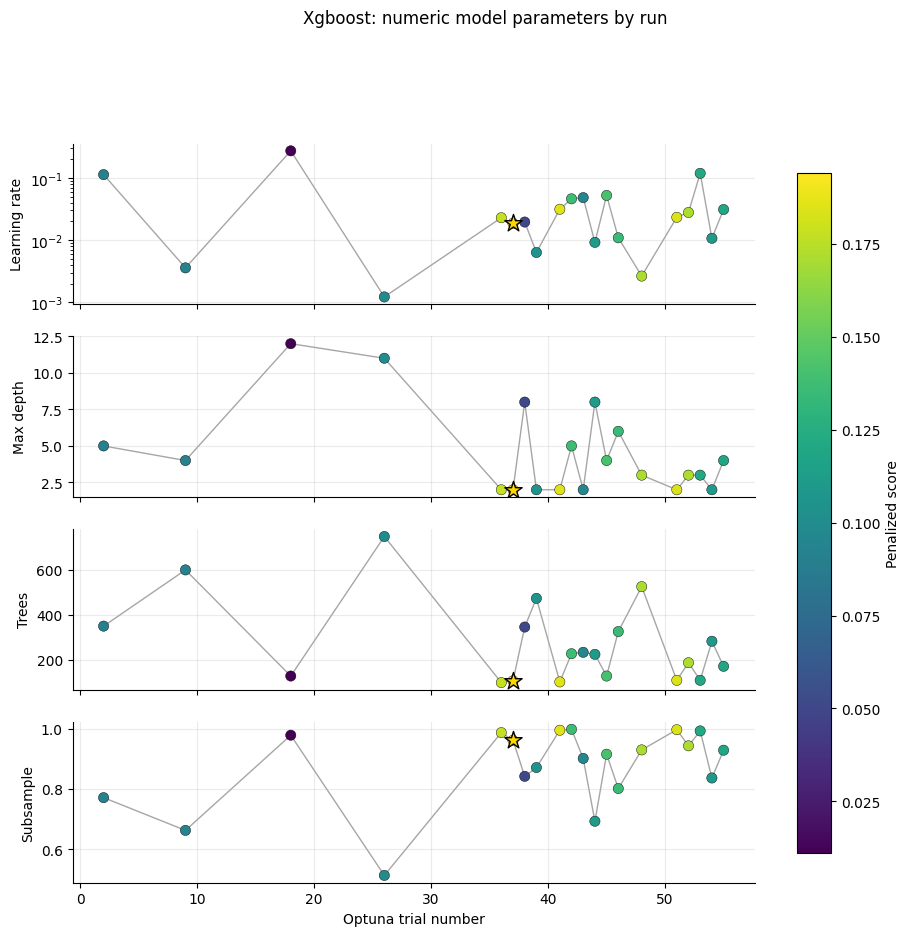

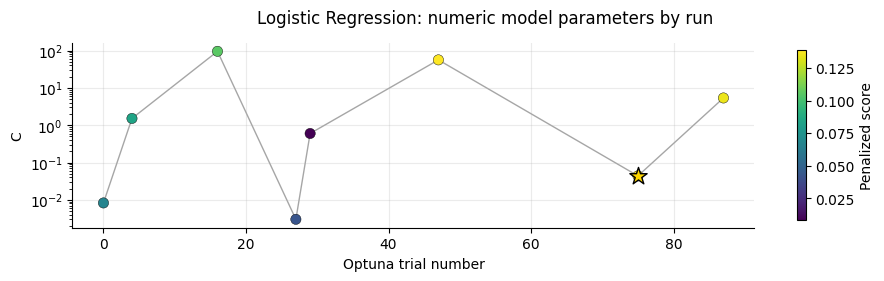

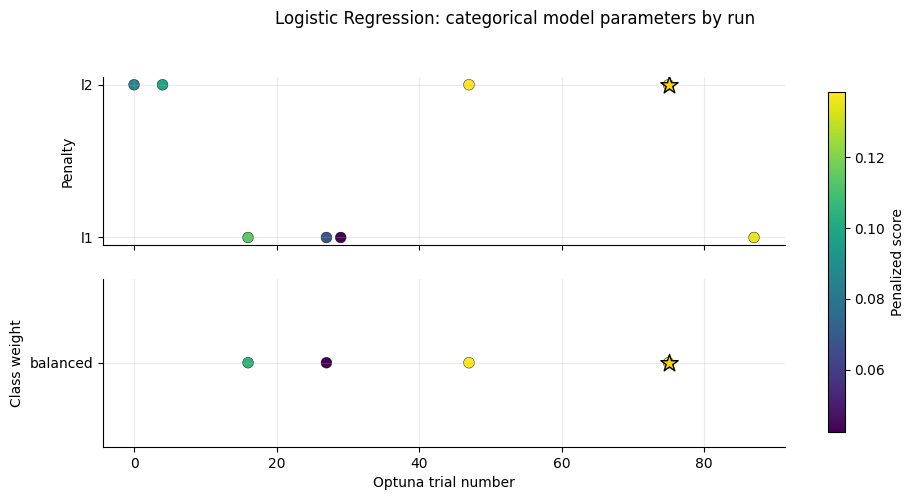

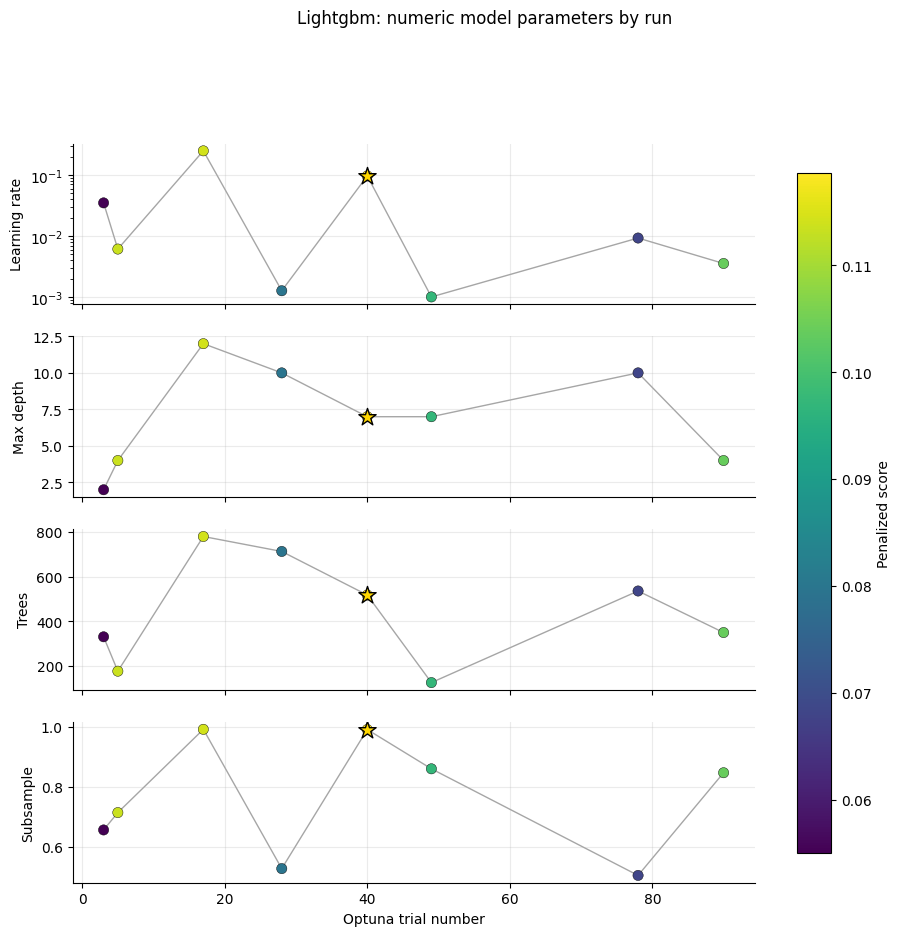

In [9]:
model_parameter_specs: dict[str, list[tuple[str, str, str, str | None]]] = {
    "logistic_regression": [
        ("params_lr_C", "C", "numeric", "log"),
        ("params_lr_penalty", "Penalty", "categorical", None),
        ("params_lr_class_weight", "Class weight", "categorical", None),
    ],
    "random_forest": [
        ("params_rf_n_estimators", "Trees", "numeric", None),
        ("params_rf_max_depth", "Max depth", "numeric", None),
        ("params_rf_min_samples_leaf", "Min samples leaf", "numeric", None),
        ("params_rf_max_features", "Max features", "categorical", None),
        ("params_rf_class_weight", "Class weight", "categorical", None),
    ],
    "xgboost": [
        ("params_xgboost_learning_rate", "Learning rate", "numeric", "log"),
        ("params_xgboost_max_depth", "Max depth", "numeric", None),
        ("params_xgboost_n_estimators", "Trees", "numeric", None),
        ("params_xgboost_subsample", "Subsample", "numeric", None),
    ],
    "lightgbm": [
        ("params_lightgbm_learning_rate", "Learning rate", "numeric", "log"),
        ("params_lightgbm_max_depth", "Max depth", "numeric", None),
        ("params_lightgbm_n_estimators", "Trees", "numeric", None),
        ("params_lightgbm_subsample", "Subsample", "numeric", None),
    ],
}

for model_family in model_families:
    model_data = trials.loc[
        trials["model_family"] == model_family
    ].sort_values("trial")
    available_specs = [
        spec
        for spec in model_parameter_specs.get(model_family, [])
        if spec[0] in model_data.columns and model_data[spec[0]].notna().any()
    ]
    numeric_specs = [spec for spec in available_specs if spec[2] == "numeric"]
    categorical_specs = [
        spec for spec in available_specs if spec[2] == "categorical"
    ]
    model_best_idx = model_data["penalized_score"].idxmax()
    family_label = model_family.replace("_", " ").title()

    if numeric_specs:
        fig, axes = plt.subplots(
            len(numeric_specs),
            1,
            figsize=(11, 2.4 * len(numeric_specs)),
            sharex=True,
            squeeze=False,
        )
        mappable = None
        for ax, (column, label, _, scale) in zip(axes.ravel(), numeric_specs):
            values = pd.to_numeric(model_data[column], errors="coerce")
            valid = values.notna() & model_data["penalized_score"].notna()
            ax.plot(
                model_data.loc[valid, "trial"],
                values.loc[valid],
                color="0.65",
                linewidth=1.0,
                zorder=1,
            )
            mappable = ax.scatter(
                model_data.loc[valid, "trial"],
                values.loc[valid],
                c=model_data.loc[valid, "penalized_score"],
                cmap="viridis",
                edgecolor="black",
                linewidth=0.3,
                s=55,
                zorder=3,
            )
            if pd.notna(values.loc[model_best_idx]):
                ax.scatter(
                    model_data.loc[model_best_idx, "trial"],
                    values.loc[model_best_idx],
                    color="gold",
                    edgecolor="black",
                    marker="*",
                    s=170,
                    zorder=5,
                )
            if scale == "log":
                ax.set_yscale("log")
            ax.set_ylabel(label)
        axes.ravel()[-1].set_xlabel("Optuna trial number")
        if mappable is not None:
            fig.colorbar(
                mappable,
                ax=axes.ravel().tolist(),
                label="Penalized score",
                shrink=0.92,
            )
        fig.suptitle(f"{family_label}: numeric model parameters by run", y=1.02)
        plt.show()

    if categorical_specs:
        fig, axes = plt.subplots(
            len(categorical_specs),
            1,
            figsize=(11, 2.4 * len(categorical_specs)),
            sharex=True,
            squeeze=False,
        )
        mappable = None
        for ax, (column, label, _, _) in zip(
            axes.ravel(), categorical_specs
        ):
            values = model_data[column].astype("string")
            categories = sorted(values.dropna().unique().tolist())
            category_positions = {
                category: position for position, category in enumerate(categories)
            }
            y_positions = values.map(category_positions)
            valid = y_positions.notna() & model_data["penalized_score"].notna()
            mappable = ax.scatter(
                model_data.loc[valid, "trial"],
                y_positions.loc[valid].astype(float),
                c=model_data.loc[valid, "penalized_score"],
                cmap="viridis",
                edgecolor="black",
                linewidth=0.3,
                s=60,
            )
            if pd.notna(y_positions.loc[model_best_idx]):
                ax.scatter(
                    model_data.loc[model_best_idx, "trial"],
                    float(y_positions.loc[model_best_idx]),
                    color="gold",
                    edgecolor="black",
                    marker="*",
                    s=170,
                    zorder=5,
                )
            ax.set_yticks(list(category_positions.values()), categories)
            ax.set_ylabel(label)
        axes.ravel()[-1].set_xlabel("Optuna trial number")
        if mappable is not None:
            fig.colorbar(
                mappable,
                ax=axes.ravel().tolist(),
                label="Penalized score",
                shrink=0.92,
            )
        fig.suptitle(
            f"{family_label}: categorical model parameters by run", y=1.02
        )
        plt.show()


## Optimization Convergence

The convergence view separates the best penalized objective from the best
raw PR-AUC observed so far. This distinction is important because the
objective rewards earlier sensor access; a trial with slightly lower PR-AUC
can still be preferable if it reaches a decision earlier.

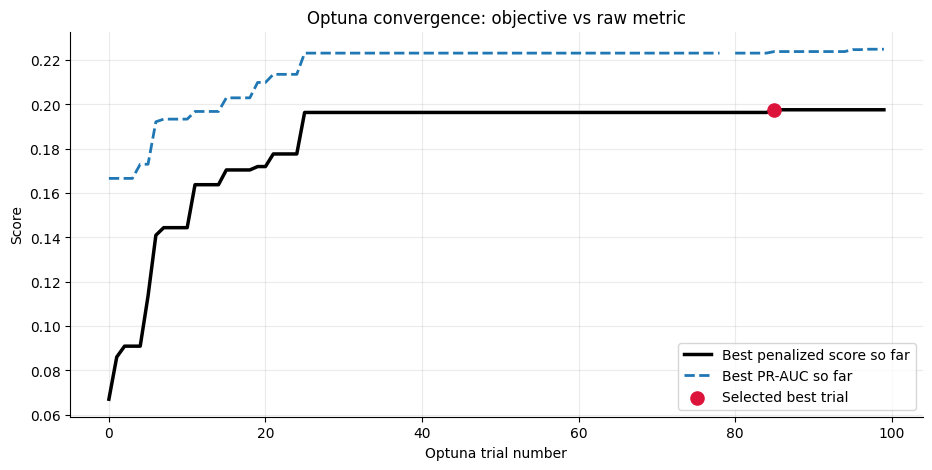

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    trials["trial"],
    trials["best_so_far_score"],
    color="black",
    linewidth=2.5,
    label="Best penalized score so far",
)
ax.plot(
    trials["trial"],
    trials["best_so_far_metric"],
    color="tab:blue",
    linewidth=2,
    linestyle="--",
    label=f"Best {metric_label} so far",
)
ax.scatter(
    [best_record["best_trial_number"]],
    [best_record["penalized_score"]],
    color="crimson",
    s=90,
    zorder=5,
    label="Selected best trial",
)
ax.set_xlabel("Optuna trial number")
ax.set_ylabel("Score")
ax.set_title("Optuna convergence: objective vs raw metric")
ax.legend()
plt.show()


## Detection Performance Versus Observation Cost

This chart frames the operational tradeoff directly: how much PR-AUC was
achieved at each observation fraction. The selected point is the best
penalized tradeoff found by the search, not necessarily the highest raw
PR-AUC point.

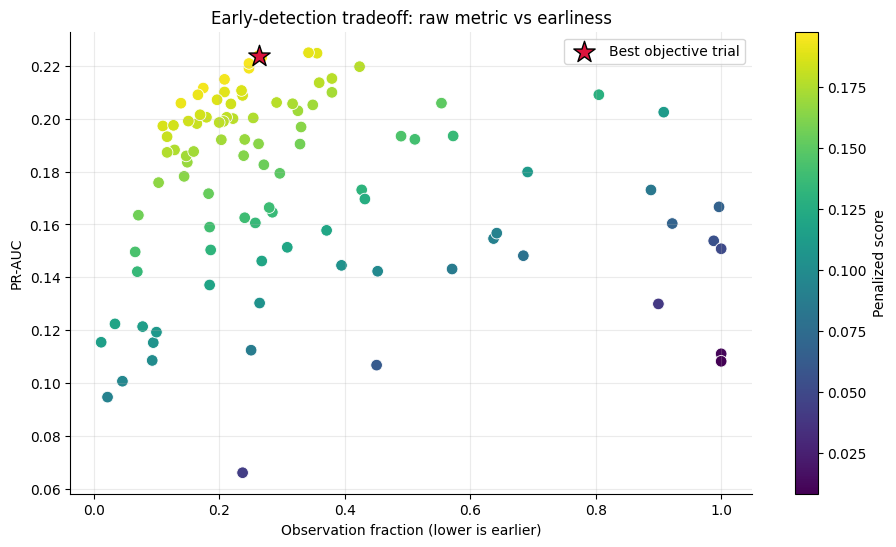

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
scatter = ax.scatter(
    trials["observation_fraction"],
    trials["detection_metric"],
    c=trials["penalized_score"],
    cmap="viridis",
    s=70,
    edgecolor="white",
    linewidth=0.6,
)
ax.scatter(
    [best_record["observation_fraction"]],
    [best_record["detection_metric"]],
    marker="*",
    color="crimson",
    edgecolor="black",
    s=260,
    label="Best objective trial",
    zorder=10,
)
ax.set_xlabel("Observation fraction (lower is earlier)")
ax.set_ylabel(metric_label)
ax.set_title("Early-detection tradeoff: raw metric vs earliness")
ax.legend(loc="best")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Penalized score")
plt.show()


## Sampled Efficiency Frontier

The sampled frontier contains trials that were not dominated by another
sampled trial with both higher PR-AUC and lower observation fraction. It is
useful for identifying efficient candidates, but it is not proof of the
true global frontier because unsampled configurations were never evaluated.

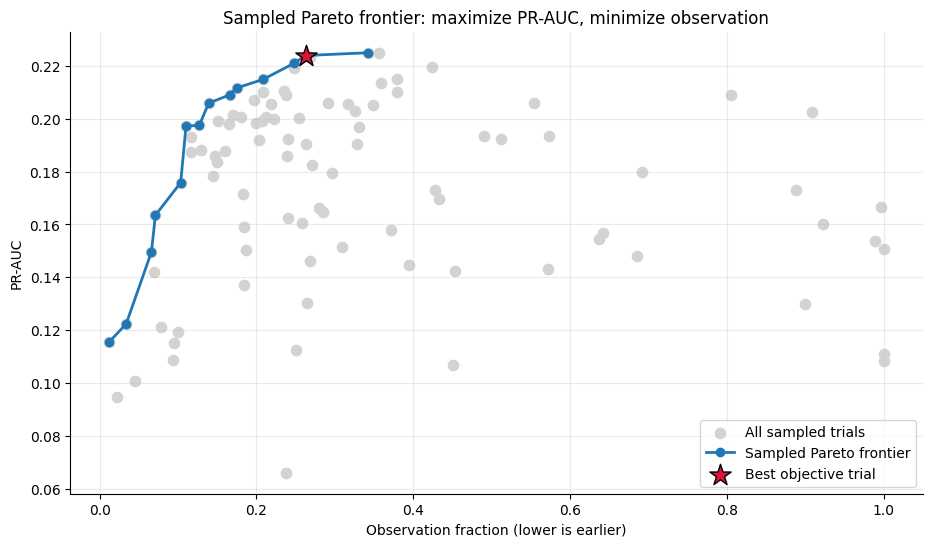

,trial,penalized_score,detection_metric,observation_fraction,latest_index,model_family
0,17,0.114269,0.115456,0.011864,7,lightgbm
1,83,0.119008,0.122397,0.033898,20,random_forest
2,82,0.143012,0.149622,0.066102,39,random_forest
3,58,0.156392,0.163510,0.071186,42,random_forest
4,84,0.165484,0.175823,0.103390,61,random_forest
5,35,0.186229,0.197246,0.110169,65,random_forest
6,77,0.184764,0.197476,0.127119,75,random_forest
7,30,0.191967,0.205865,0.138983,82,random_forest
8,63,0.192428,0.209038,0.166102,98,random_forest
9,56,0.194120,0.211577,0.174576,103,random_forest


In [12]:
frontier_source = trials.dropna(
    subset=["observation_fraction", "detection_metric"]
).sort_values(["observation_fraction", "detection_metric"], ascending=[True, False])

frontier_indices: list[int] = []
best_metric_seen = -np.inf
for idx, row in frontier_source.iterrows():
    metric = float(row["detection_metric"])
    if metric > best_metric_seen:
        frontier_indices.append(idx)
        best_metric_seen = metric

frontier = trials.loc[frontier_indices].sort_values("observation_fraction")

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(
    trials["observation_fraction"],
    trials["detection_metric"],
    color="lightgray",
    s=55,
    label="All sampled trials",
)
ax.plot(
    frontier["observation_fraction"],
    frontier["detection_metric"],
    marker="o",
    color="tab:blue",
    linewidth=2,
    label="Sampled Pareto frontier",
)
ax.scatter(
    [best_record["observation_fraction"]],
    [best_record["detection_metric"]],
    marker="*",
    color="crimson",
    edgecolor="black",
    s=260,
    label="Best objective trial",
    zorder=10,
)
ax.set_xlabel("Observation fraction (lower is earlier)")
ax.set_ylabel(metric_label)
ax.set_title("Sampled Pareto frontier: maximize PR-AUC, minimize observation")
ax.legend(loc="best")
plt.show()

display(
    frontier[["trial", "penalized_score", "detection_metric", "observation_fraction", "latest_index", "model_family"]]
    .sort_values("observation_fraction")
    .reset_index(drop=True)
)


## Configuration Segment Effects

These boxplots summarize the objective distribution across major
categorical search choices. Because Optuna adaptively samples promising
regions, category counts are unequal; interpret the medians and spread as
directional evidence from this search, not as balanced experimental effects.

C:\Users\Virgil\AppData\Local\Temp\ipykernel_28240\2485884594.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=labels, showmeans=True)
C:\Users\Virgil\AppData\Local\Temp\ipykernel_28240\2485884594.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=labels, showmeans=True)
C:\Users\Virgil\AppData\Local\Temp\ipykernel_28240\2485884594.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=labels, showmeans=True)


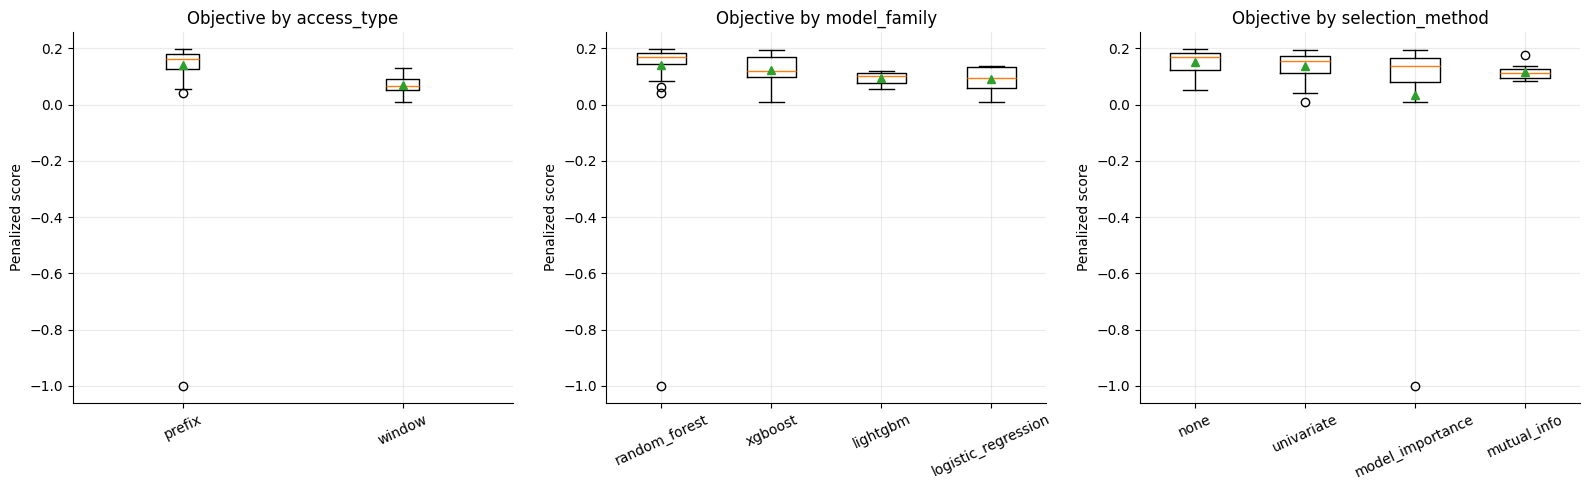

In [13]:
def boxplot_by_category(category: str, ax: plt.Axes) -> None:
    summary = (
        trials.dropna(subset=[category, "penalized_score"])
        .groupby(category, observed=True)["penalized_score"]
        .median()
        .sort_values(ascending=False)
    )
    labels = list(summary.index)
    values = [
        trials.loc[trials[category] == label, "penalized_score"].dropna()
        for label in labels
    ]
    ax.boxplot(values, labels=labels, showmeans=True)
    ax.set_title(f"Objective by {category}")
    ax.set_ylabel("Penalized score")
    ax.tick_params(axis="x", rotation=25)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for category, ax in zip(
    ["access_type", "model_family", "selection_method"], axes
):
    boxplot_by_category(category, ax)
fig.tight_layout()
plt.show()


## Report Conclusion

The current handoff candidate is trial 85, a random-forest prefix
model that achieved the best penalized objective in the completed
study. The result is operationally plausible because it reaches a
decision after roughly one quarter of the sensor sequence while
maintaining the strongest objective among sampled configurations.

XGBoost remains the most relevant challenger: its best trial was
close on objective and used an earlier observation fraction. A
production decision should therefore compare the selected random
forest and the strongest challenger on a held-out evaluation set
with the full operating metrics required by the business, including
ROC-AUC, precision, recall, false-pass rate, and expected cost.